# NSW Transit Weather Resilience — Model Training & Evaluation

In [2]:
import os
import sys
import json
import warnings
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import shap

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sys.path.insert(0, str(Path("..").resolve()))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

PARQUET_DIR   = Path("../data/parquet")
TRAINING_PATH = PARQUET_DIR / "training_dataset.parquet"
MODELS_DIR    = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

_SYDNEY_TZ = ZoneInfo("Australia/Sydney")
print(f"TRAINING_PATH : {TRAINING_PATH}")
print(f"MODELS_DIR    : {MODELS_DIR}")


TRAINING_PATH : ../data/parquet/training_dataset.parquet
MODELS_DIR    : ../models


## 1. Load Training Dataset

Build the dataset first if it doesn't exist:
```bash
uv run python -m app.ml.train --skip-terminus
```

In [3]:
if not TRAINING_PATH.exists():
    print(f'Training dataset not found — building now (this may take a few minutes) ...')
    print('Tip: re-run with skip_terminus_distance=True if MySQL is not available locally.')
    import asyncio
    from dotenv import load_dotenv
    load_dotenv(Path('..') / '.env')
    from app.ml.dataset import build_training_dataset
        # Jupyter supports top-level await; scripts can use asyncio.run()
    try:
        df = await build_training_dataset(skip_terminus_distance=True)
    except RuntimeError:
        import asyncio
        df = asyncio.run(build_training_dataset(skip_terminus_distance=True))
    print(f'Dataset built: {df.shape}')
else:
    df = pd.read_parquet(TRAINING_PATH)
    print(f'Loaded existing dataset.')

print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:')
print(df.dtypes.to_string())
print(f'\nFirst 3 rows:')
print(df.head(3).to_string())
print(f'\nline_group value_counts:')
print(df['line_group'].value_counts(dropna=False).to_string())
print(f'\nschedule_relationship value_counts:')
print(df['schedule_relationship'].value_counts(dropna=False).to_string())


Loaded existing dataset.
Shape: (884736, 22)

Column dtypes:
trip_id                                                  str
route_id                                                 str
stop_id                                                  str
timestamp                   datetime64[us, Australia/Sydney]
delay_seconds                                          int64
is_incident_active                                      int8
schedule_relationship                                    str
vehicle_id                                             Int32
nearest_station_id                                       str
air_temp_c                                           float64
rain_trace_mm                                        float64
wind_gust_kmh                                        float64
occupancy_status                                      object
hour                                                    int8
day_of_week                                             int8
is_weekend              

## 2. Feature Preparation

In [4]:
# Feature definitions — must match app/ml/train.py exactly
ALL_FEATURES = [
    'air_temp_c', 'rain_trace_mm', 'wind_gust_kmh',
    'hour', 'day_of_week', 'distance_to_terminus', 'occupancy_encoded',
    'is_peak_hour', 'is_weekend', 'is_incident_active', 'is_ghost_train',
    'line_group',
]
CATEGORICAL_FEATURES = ['line_group']
REGRESSION_TARGET     = 'delay_seconds'
CLASSIFICATION_TARGET = 'is_significantly_delayed'

# ── Drop 100%-null features (e.g. occupancy_encoded when vehicle_id is absent) ──
null_pct = df[ALL_FEATURES].isnull().mean()
dead_cols = null_pct[null_pct == 1.0].index.tolist()
if dead_cols:
    print(f'Dropping 100%-null features (no data in this collection period): {dead_cols}')
active_features = [f for f in ALL_FEATURES if f not in dead_cols]
active_cats     = [f for f in CATEGORICAL_FEATURES if f not in dead_cols]

X = df[active_features].copy()
X['line_group'] = pd.Categorical(X['line_group'])
for col in ['distance_to_terminus', 'occupancy_encoded']:
    if col in X.columns:
        X[col] = X[col].astype('float64')

# ── Clip corrupt outliers from GTFS-R timestamp arithmetic errors ──────────
# Floor is 0 (not -300) because Tweedie regression requires y ≥ 0.
# Only ~30 rows have delay < 0 (<0.01% of data) so information loss is
# negligible.  Ceiling 3600s = +60 min maximum credible delay.
DELAY_MIN, DELAY_MAX = 0, 3600
raw_delay = df[REGRESSION_TARGET].astype('float32')
n_clipped = int((raw_delay.clip(DELAY_MIN, DELAY_MAX) != raw_delay).sum())
print(f'Clipping delay_seconds to [{DELAY_MIN}, {DELAY_MAX}] — '
      f'{n_clipped:,} rows affected ({n_clipped/len(raw_delay)*100:.3f}%)')

y_reg = raw_delay.clip(DELAY_MIN, DELAY_MAX)
y_cls = df[CLASSIFICATION_TARGET].astype('int8')

print(f'\nActive features ({len(active_features)}):', active_features)
print(f'\nDelay distribution after clipping:')
print(f'  mean={y_reg.mean():.1f}s  median={y_reg.median():.1f}s  '
      f'std={y_reg.std():.1f}s  p95={y_reg.quantile(0.95):.0f}s')
print(f'  exactly 0: {(y_reg == 0).mean()*100:.1f}%')
print(f'\nClassification balance:')
vc = y_cls.value_counts().sort_index()
for val, cnt in vc.items():
    label = '>5 min late' if val == 1 else 'on-time'
    print(f'  {label}: {cnt:,} ({cnt/len(y_cls)*100:.2f}%)')

# Null summary for active features
partial_nulls = null_pct[(null_pct > 0) & (null_pct < 1.0)]
if not partial_nulls.empty:
    print(f'\nPartial-null features (LightGBM handles natively):')
    for col, pct in partial_nulls.sort_values(ascending=False).items():
        print(f'  {col}: {pct*100:.1f}% null')


Dropping 100%-null features (no data in this collection period): ['occupancy_encoded']
Clipping delay_seconds to [0, 3600] — 1,265 rows affected (0.143%)

Active features (11): ['air_temp_c', 'rain_trace_mm', 'wind_gust_kmh', 'hour', 'day_of_week', 'distance_to_terminus', 'is_peak_hour', 'is_weekend', 'is_incident_active', 'is_ghost_train', 'line_group']

Delay distribution after clipping:
  mean=58.6s  median=0.0s  std=241.3s  p95=250s
  exactly 0: 64.5%

Classification balance:
  on-time: 850,563 (96.14%)
  >5 min late: 34,173 (3.86%)

Partial-null features (LightGBM handles natively):
  distance_to_terminus: 36.6% null
  wind_gust_kmh: 34.3% null
  rain_trace_mm: 4.7% null
  air_temp_c: 3.7% null


## 3. Temporal Train / Test Split

Train: 757,524 rows  (2026-03-31 → 2026-04-18)
Test:  127,212 rows  (2026-04-18 → 2026-04-21)

Train delay — mean: 59.5s  std: 249.7s
Test  delay — mean: 53.7s  std: 183.4s

Train2: 681,771 | Val: 75,753 (for early stopping)


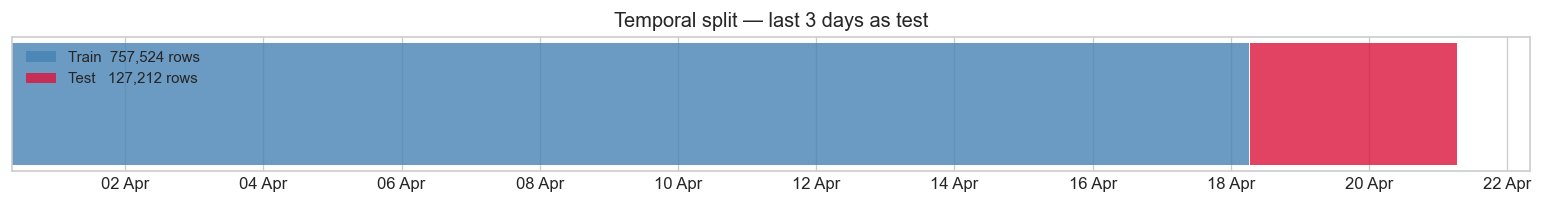

In [5]:
ts = pd.to_datetime(df['timestamp'], utc=True)

# Chronological sort — essential for a correct temporal split
sort_idx = ts.argsort()
X     = X.iloc[sort_idx].reset_index(drop=True)
y_reg = y_reg.iloc[sort_idx].reset_index(drop=True)
y_cls = y_cls.iloc[sort_idx].reset_index(drop=True)
ts    = ts.iloc[sort_idx].reset_index(drop=True)

# Last 3 days = test  (3 days ≈ 15% of 20-day dataset)
# 7 days was 35% — too large given the small total window, and it spans
# the parquet-reset boundary which creates a distribution shift.
TEST_DAYS = 3
cutoff    = ts.max() - pd.Timedelta(days=TEST_DAYS)
train_mask = ts <= cutoff
test_mask  = ~train_mask

X_tr, X_te       = X[train_mask], X[test_mask]
y_reg_tr, y_reg_te = y_reg[train_mask], y_reg[test_mask]
y_cls_tr, y_cls_te = y_cls[train_mask], y_cls[test_mask]
ts_tr, ts_te     = ts[train_mask], ts[test_mask]

print(f'Train: {len(X_tr):,} rows  ({ts_tr.min().date()} → {ts_tr.max().date()})')
print(f'Test:  {len(X_te):,} rows  ({ts_te.min().date()} → {ts_te.max().date()})')
print(f'\nTrain delay — mean: {y_reg_tr.mean():.1f}s  std: {y_reg_tr.std():.1f}s')
print(f'Test  delay — mean: {y_reg_te.mean():.1f}s  std: {y_reg_te.std():.1f}s')

# Internal val split from training set (last 10%) for early stopping
val_cut = int(len(X_tr) * 0.9)
X_tr2, X_val     = X_tr.iloc[:val_cut], X_tr.iloc[val_cut:]
y_reg_tr2, y_reg_val = y_reg_tr.iloc[:val_cut], y_reg_tr.iloc[val_cut:]
y_cls_tr2, y_cls_val = y_cls_tr.iloc[:val_cut], y_cls_tr.iloc[val_cut:]
print(f'\nTrain2: {len(X_tr2):,} | Val: {len(X_val):,} (for early stopping)')

# ── Timeline bar chart ────────────────────────────────────────────────────
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(13, 1.8))
t0 = ts_tr.min().to_pydatetime()
t1 = ts_tr.max().to_pydatetime()
t2 = ts_te.min().to_pydatetime()
t3 = ts_te.max().to_pydatetime()

to_num = mdates.date2num
ax.barh(0, to_num(t1) - to_num(t0), left=to_num(t0), height=0.5,
        color='steelblue', alpha=0.8, label=f'Train  {len(X_tr):,} rows')
ax.barh(0, to_num(t3) - to_num(t2), left=to_num(t2), height=0.5,
        color='crimson',   alpha=0.8, label=f'Test   {len(X_te):,} rows')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.set_yticks([])
ax.set_title(f'Temporal split — last {TEST_DAYS} days as test')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 4. LightGBM Delay Regressor

Predicts `delay_seconds` directly.

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[17]	train's rmse: 251.399	val's rmse: 100.708

Best iteration: 17
Best val RMSE:   100.7080 s


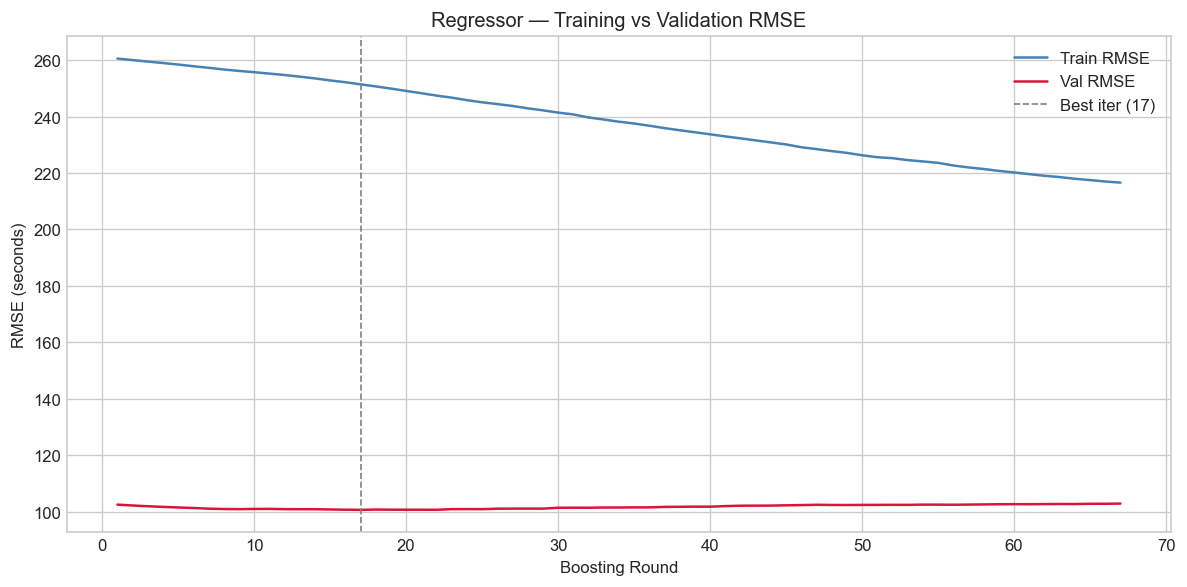

In [6]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

LGB_REG_PARAMS = dict(
    objective="tweedie",
    tweedie_variance_power=1.5,
    metric="rmse",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    verbose=-1,
)

reg = LGBMRegressor(**LGB_REG_PARAMS)

reg.fit(
    X_tr2, y_reg_tr2,
    eval_set=[(X_tr2, y_reg_tr2), (X_val, y_reg_val)],
    eval_names=["train", "val"],
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100),
    ],
    categorical_feature=active_cats,
)

print(f"\nBest iteration: {reg.best_iteration_}")
print(f"Best val RMSE:   {reg.best_score_['val']['rmse']:.4f} s")

evals = reg.evals_result_
train_mae = evals["train"]["rmse"]
val_mae = evals["val"]["rmse"]
iters = range(1, len(train_mae) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iters, train_mae, label="Train RMSE", color="steelblue", lw=1.5)
ax.plot(iters, val_mae, label="Val RMSE", color="crimson", lw=1.5)
ax.axvline(reg.best_iteration_, color="gray", ls="--", lw=1, label=f"Best iter ({reg.best_iteration_})")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE (seconds)")
ax.set_title("Regressor — Training vs Validation RMSE")
ax.legend()

plt.tight_layout()
plt.show()

## 4.1 Regressor Evaluation

Regressor Test Performance:
  MAE  : 74.47 seconds
  RMSE : 182.06 seconds
  R²   : 0.0144


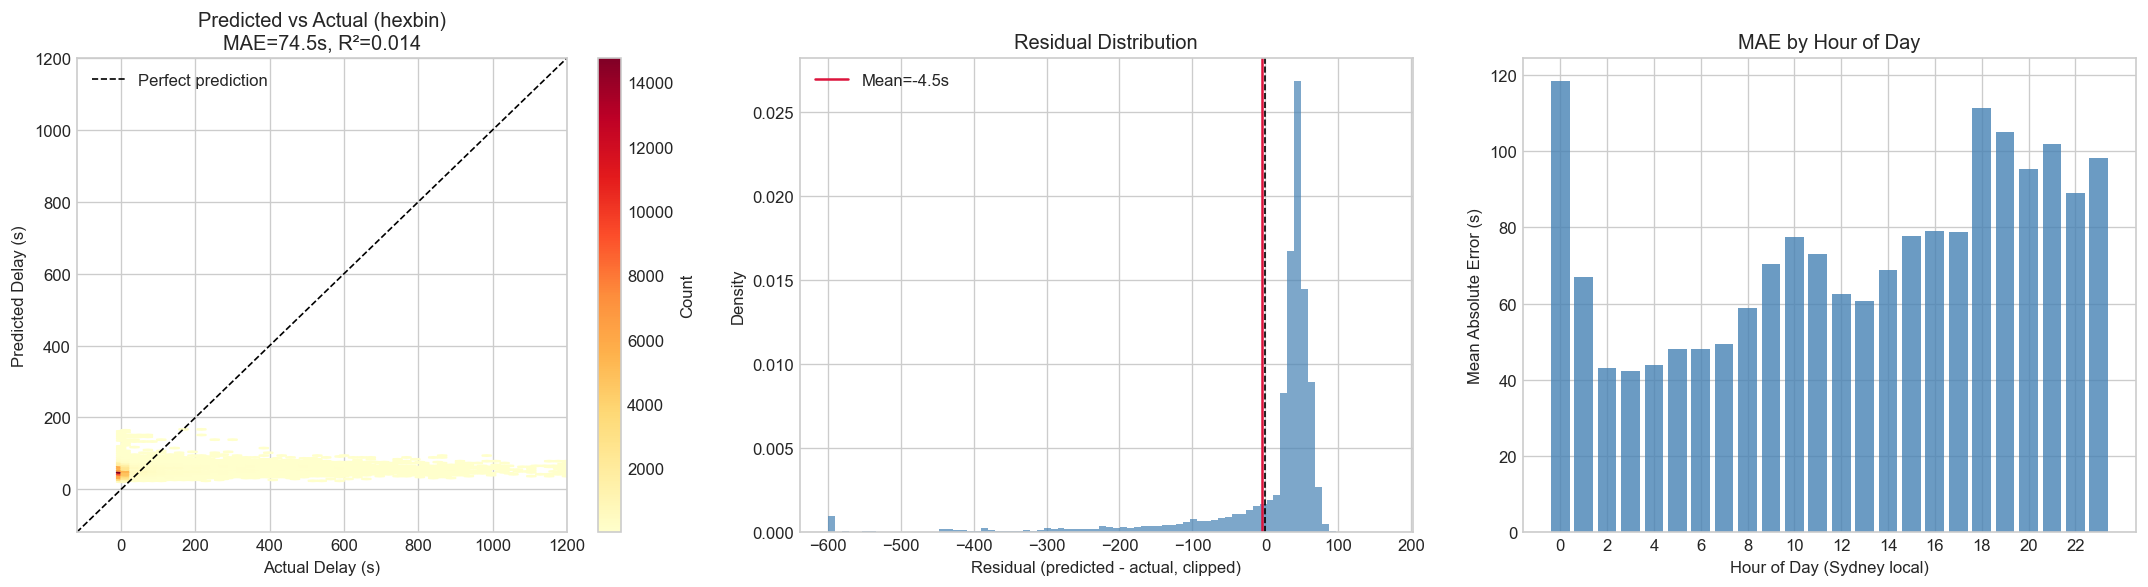

In [7]:
y_reg_pred = reg.predict(X_te)

mae = mean_absolute_error(y_reg_te, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_te, y_reg_pred))
r2 = r2_score(y_reg_te, y_reg_pred)

print(f"Regressor Test Performance:")
print(f"  MAE  : {mae:.2f} seconds")
print(f"  RMSE : {rmse:.2f} seconds")
print(f"  R²   : {r2:.4f}")

# Sydney local hour for test set
sydney_tz = _SYDNEY_TZ  # ZoneInfo("Australia/Sydney") — set in setup cell
ts_te_local = ts_te.dt.tz_convert(_SYDNEY_TZ)
hour_te = ts_te_local.dt.hour

actual_clip = np.clip(y_reg_te.values, -120, 1200)
pred_clip = np.clip(y_reg_pred, -120, 1200)
residuals = y_reg_pred - y_reg_te.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Hexbin scatter: predicted vs actual
ax = axes[0]
hb = ax.hexbin(actual_clip, pred_clip, gridsize=50, cmap="YlOrRd", mincnt=1)
plt.colorbar(hb, ax=ax, label="Count")
lims = [-120, 1200]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Delay (s)")
ax.set_ylabel("Predicted Delay (s)")
ax.set_title(f"Predicted vs Actual (hexbin)\nMAE={mae:.1f}s, R²={r2:.3f}")
ax.legend()

# (b) Residual histogram
ax = axes[1]
res_clipped = np.clip(residuals, -600, 600)
ax.hist(res_clipped, bins=80, color="steelblue", alpha=0.7, density=True)
ax.axvline(0, color="black", lw=1, ls="--")
ax.axvline(np.mean(residuals), color="crimson", lw=1.5, ls="-", label=f"Mean={np.mean(residuals):.1f}s")
ax.set_xlabel("Residual (predicted - actual, clipped)")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution")
ax.legend()

# (c) MAE by hour of day
ax = axes[2]
hour_mae = (
    pd.DataFrame({"hour": hour_te.values, "abs_err": np.abs(residuals)})
    .groupby("hour")["abs_err"]
    .mean()
    .reindex(range(24))
)
ax.bar(range(24), hour_mae.values, color="steelblue", alpha=0.8)
ax.set_xlabel("Hour of Day (Sydney local)")
ax.set_ylabel("Mean Absolute Error (s)")
ax.set_title("MAE by Hour of Day")
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 5. LightGBM Delay Classifier

Predicts whether delay > 5 minutes.

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	train's auc: 0.821195	val's auc: 0.540799

Best iteration: 5
Best val AUC:   0.5408


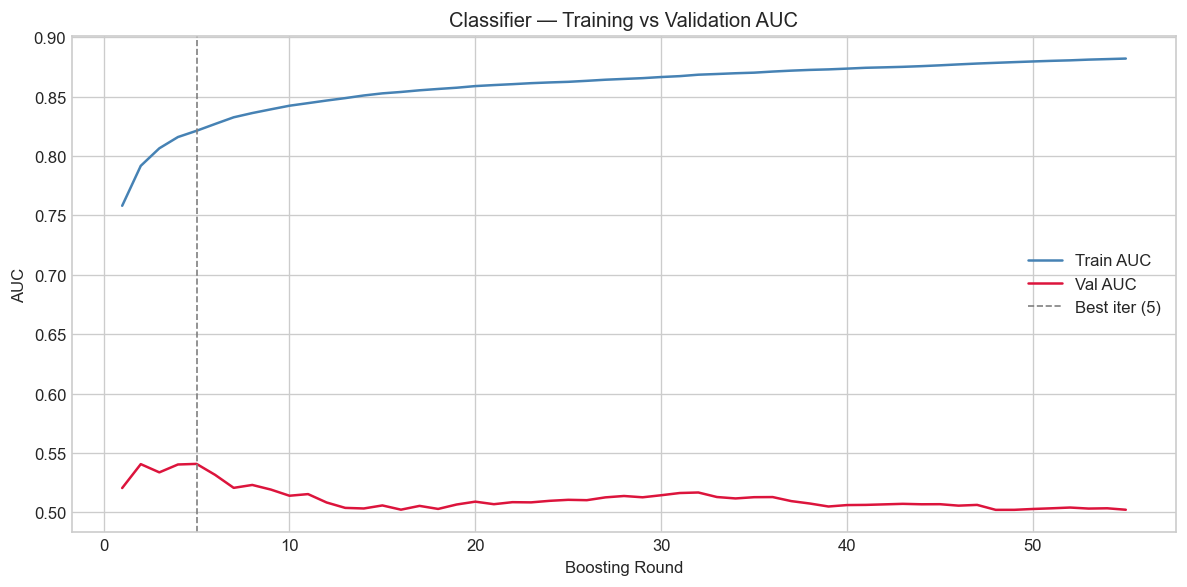

In [8]:
# scale_pos_weight replaces is_unbalance=True — sets the exact neg/pos ratio.
from lightgbm import LGBMClassifier

LGB_CLS_PARAMS = dict(
    objective="binary",
    metric="auc",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    verbose=-1,
    scale_pos_weight=25,  # ≈ 96.1% / 3.9%: upweights rare 'delayed' class
)

cls = LGBMClassifier(**LGB_CLS_PARAMS)

cls.fit(
    X_tr2, y_cls_tr2,
    eval_set=[(X_tr2, y_cls_tr2), (X_val, y_cls_val)],
    eval_names=["train", "val"],
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100),
    ],
    categorical_feature=active_cats,
)

print(f"\nBest iteration: {cls.best_iteration_}")
print(f"Best val AUC:   {cls.best_score_['val']['auc']:.4f}")

# Learning curve
cls_evals = cls.evals_result_
train_auc = cls_evals["train"]["auc"]
val_auc = cls_evals["val"]["auc"]
iters = range(1, len(train_auc) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iters, train_auc, label="Train AUC", color="steelblue", lw=1.5)
ax.plot(iters, val_auc, label="Val AUC", color="crimson", lw=1.5)
ax.axvline(cls.best_iteration_, color="gray", ls="--", lw=1, label=f"Best iter ({cls.best_iteration_})")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("AUC")
ax.set_title("Classifier — Training vs Validation AUC")
ax.legend()

plt.tight_layout()
plt.show()

## 5.1 Classifier Evaluation

Classification Report (threshold=0.5):
                       precision    recall  f1-score   support

          Not Delayed       0.95      1.00      0.98    121107
Significantly Delayed       0.00      0.00      0.00      6105

             accuracy                           0.95    127212
            macro avg       0.48      0.50      0.49    127212
         weighted avg       0.91      0.95      0.93    127212

ROC-AUC: 0.6141
F1 (sig. delayed): 0.0000


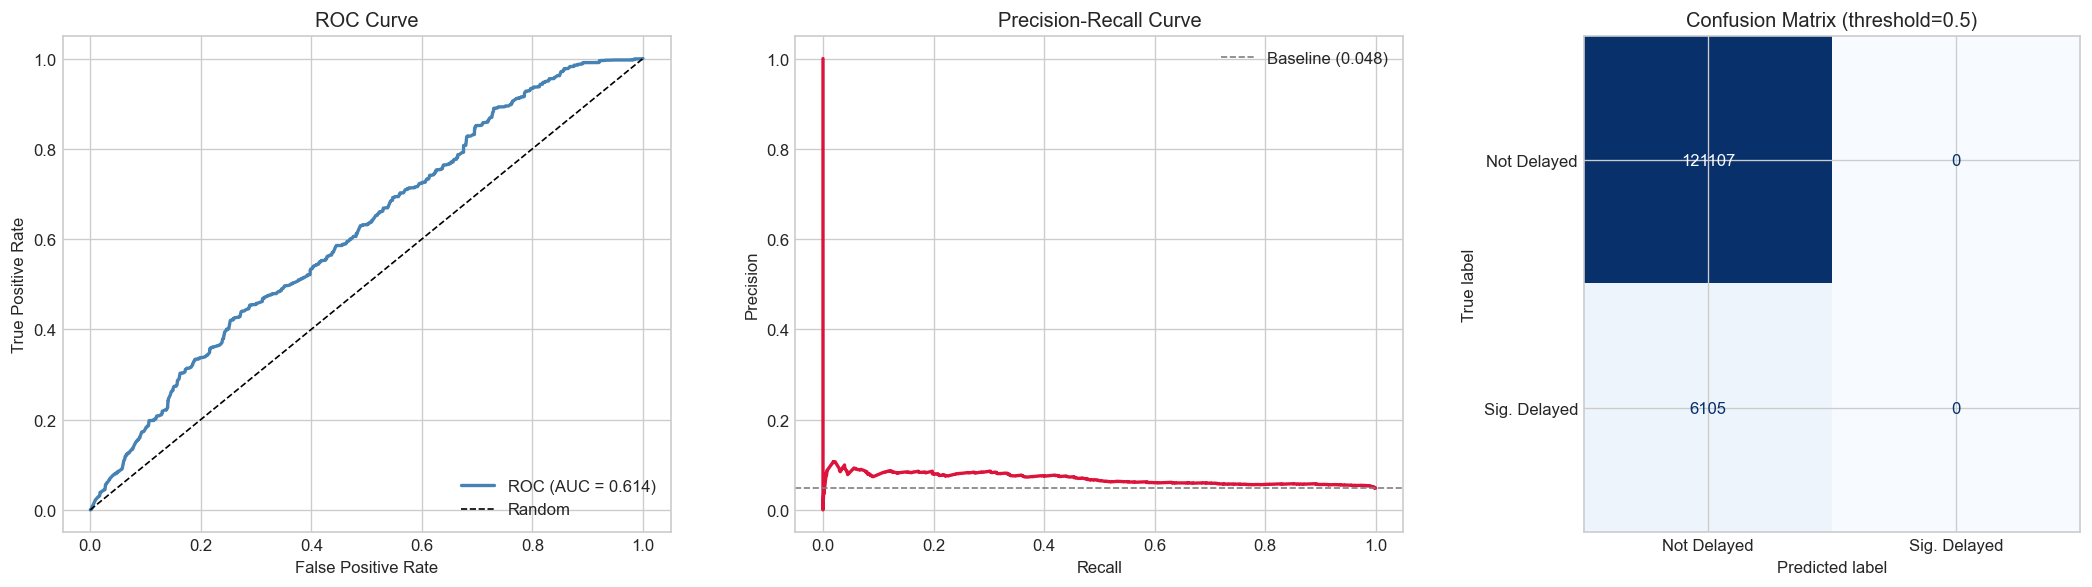

In [9]:
from sklearn.metrics import precision_recall_curve, roc_curve

y_cls_prob = cls.predict_proba(X_te)[:, 1]
custom_threshold = 0.15
y_cls_pred = (y_cls_prob >= 0.5).astype(int)  # start at 0.5, scan PR curve below

auc = roc_auc_score(y_cls_te, y_cls_prob)
f1 = f1_score(y_cls_te, y_cls_pred)

print("Classification Report (threshold=0.5):")
print(classification_report(y_cls_te, y_cls_pred, target_names=["Not Delayed", "Significantly Delayed"]))
print(f"ROC-AUC: {auc:.4f}")
print(f"F1 (sig. delayed): {f1:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) ROC curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y_cls_te, y_cls_prob)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")

# (b) Precision-Recall curve
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_cls_te, y_cls_prob)
ax.plot(rec, prec, color="crimson", lw=2)
baseline = y_cls_te.mean()
ax.axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline ({baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

# (c) Confusion matrix
ax = axes[2]
cm = confusion_matrix(y_cls_te, y_cls_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delayed", "Sig. Delayed"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (threshold=0.5)")

plt.tight_layout()
plt.show()

## 6. SHAP Feature Importance

SHAP Summary — Mean |SHAP| per feature (bar):


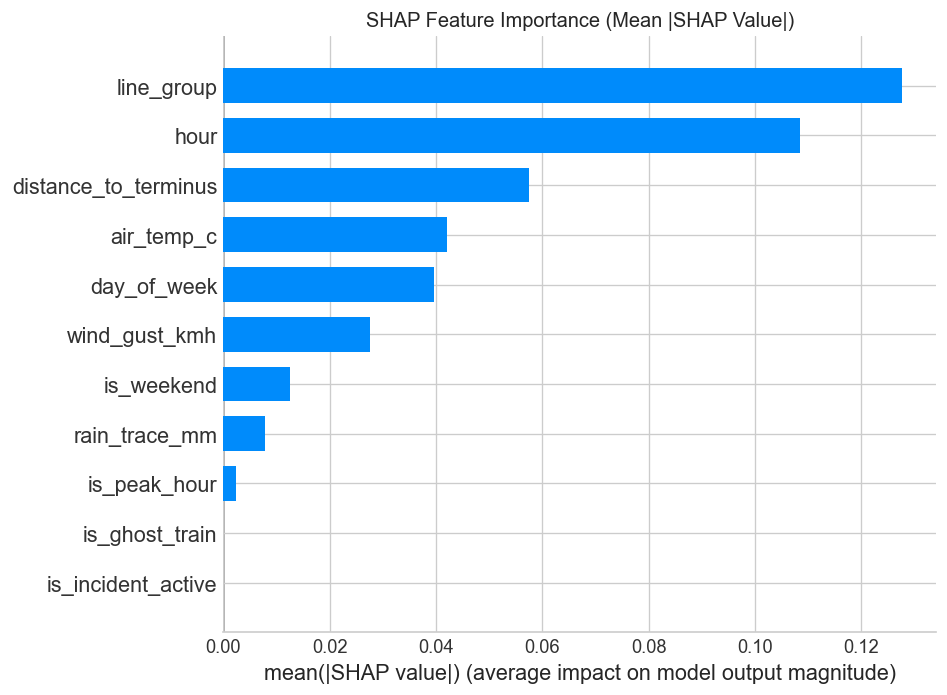

SHAP Summary — Beeswarm:


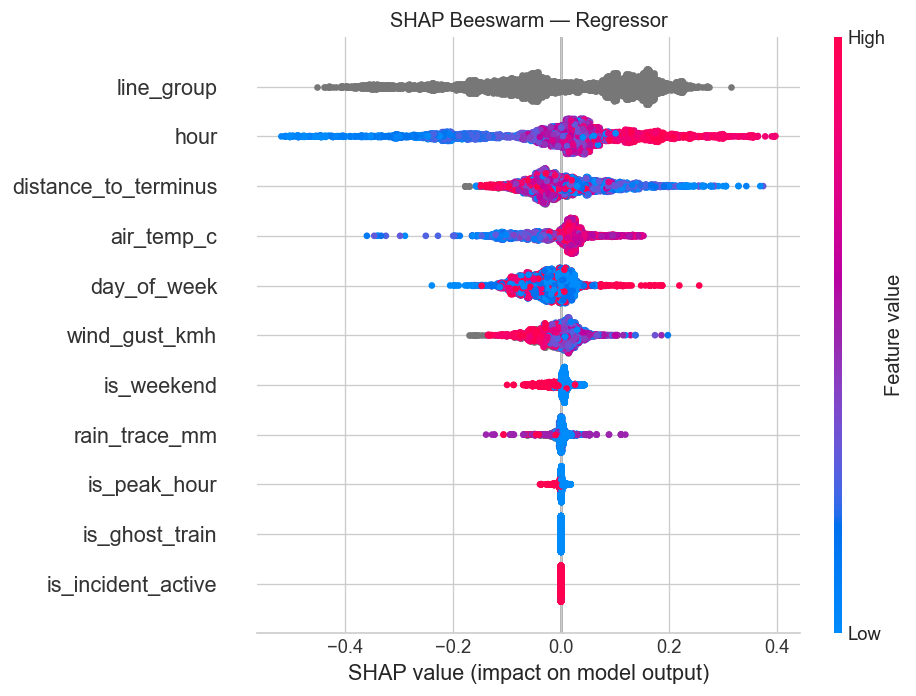

SHAP Dependence Plot: rain_trace_mm (coloured by is_incident_active):


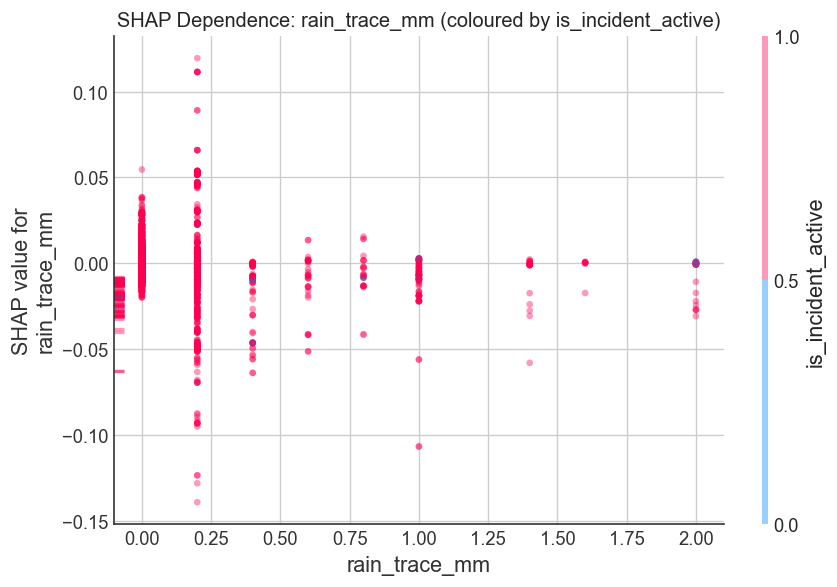

SHAP Dependence Plot: air_temp_c (coloured by is_incident_active):


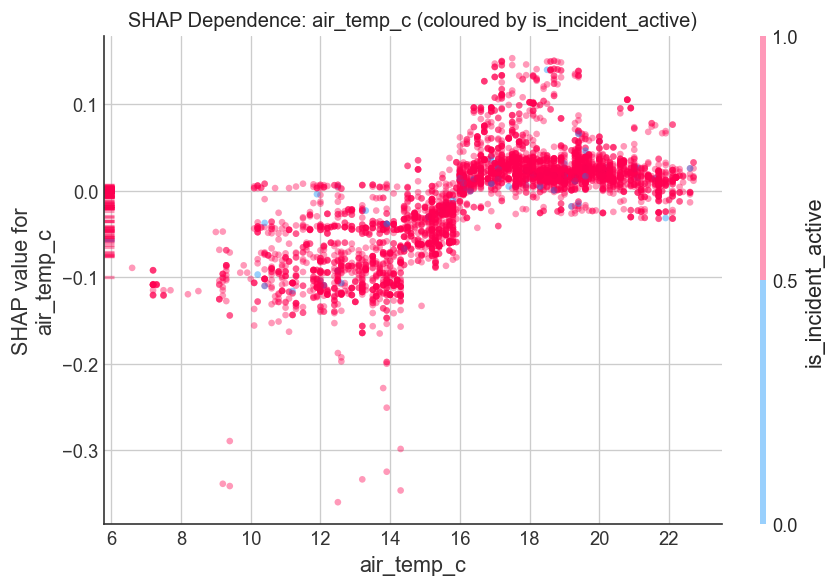

SHAP Dependence Plot: wind_gust_kmh (coloured by is_incident_active):


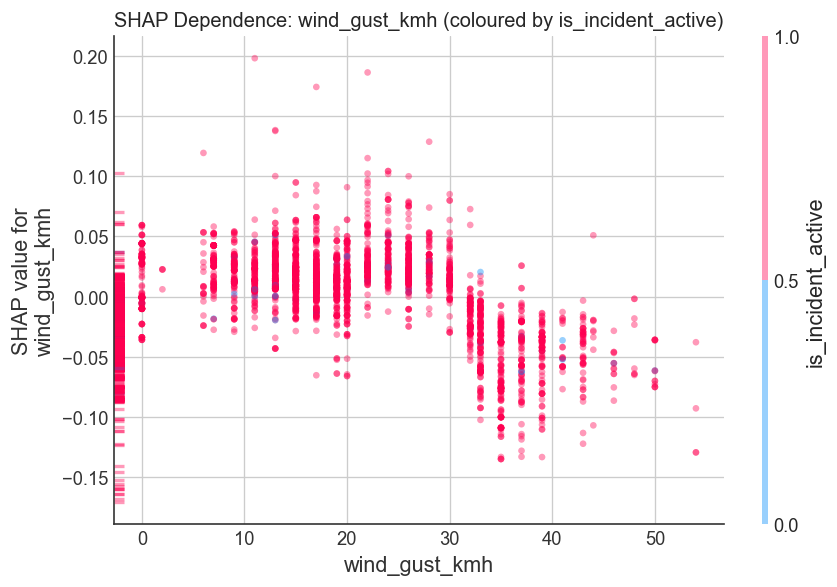

In [10]:
# Sample 5000 rows from test set for SHAP
rng = np.random.default_rng(42)
shap_idx = rng.choice(len(X_te), size=min(5000, len(X_te)), replace=False)
X_shap = X_te.iloc[shap_idx].reset_index(drop=True)

# SHAP TreeExplainer on regressor booster
explainer = shap.TreeExplainer(reg.booster_)
shap_values = explainer.shap_values(X_shap)

# (a) Bar plot — mean |SHAP| per feature
print("SHAP Summary — Mean |SHAP| per feature (bar):")
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)")
plt.tight_layout()
plt.show()

# (b) Beeswarm dot plot
print("SHAP Summary — Beeswarm:")
shap.summary_plot(shap_values, X_shap, plot_type="dot", show=False)
plt.title("SHAP Beeswarm — Regressor")
plt.tight_layout()
plt.show()

# (c) Dependence plots for each weather feature
weather_shap_features = ["rain_trace_mm", "air_temp_c", "wind_gust_kmh"]
interaction_feature = "is_incident_active"

for feat in weather_shap_features:
    if feat not in X_shap.columns:
        print(f"Feature {feat} not in X_shap, skipping.")
        continue
    feat_idx = list(X_shap.columns).index(feat)
    int_idx = list(X_shap.columns).index(interaction_feature) if interaction_feature in X_shap.columns else "auto"
    print(f"SHAP Dependence Plot: {feat} (coloured by {interaction_feature}):")
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_shap,
        interaction_index=int_idx,
        show=False,
        alpha=0.4,
    )
    plt.title(f"SHAP Dependence: {feat} (coloured by {interaction_feature})")
    plt.tight_layout()
    plt.show()

## 7. Save Models

In [11]:
reg_path = MODELS_DIR / "delay_regressor.lgbm"
cls_path = MODELS_DIR / "delay_classifier.lgbm"

reg.booster_.save_model(str(reg_path))
print(f"Saved regressor booster -> {reg_path}")

cls.booster_.save_model(str(cls_path))
print(f"Saved classifier booster -> {cls_path}")

# Determine line_group categories
if hasattr(X["line_group"], "cat"):
    line_group_categories = X["line_group"].cat.categories.tolist()
else:
    line_group_categories = sorted(X["line_group"].dropna().unique().tolist())

numeric_features = [f for f in ALL_FEATURES if f not in CATEGORICAL_FEATURES]
binary_features = [
    f for f in numeric_features
    if f in ["is_weekend", "is_peak_hour", "is_incident_active", "is_ghost_train"]
]

feature_meta = {
    "feature_cols": ALL_FEATURES,
    "numeric_features": numeric_features,
    "binary_features": binary_features,
    "categorical_features": CATEGORICAL_FEATURES,
    "line_group_categories": line_group_categories,
    "regression_target": REGRESSION_TARGET,
    "classification_target": CLASSIFICATION_TARGET,
    "significant_delay_threshold_seconds": 300,
}

meta_path = MODELS_DIR / "feature_meta.json"
with open(meta_path, "w") as f:
    json.dump(feature_meta, f, indent=2)
print(f"Saved feature_meta.json -> {meta_path}")

print("\nfeature_meta contents:")
print(json.dumps(feature_meta, indent=2))

Saved regressor booster -> ../models/delay_regressor.lgbm
Saved classifier booster -> ../models/delay_classifier.lgbm
Saved feature_meta.json -> ../models/feature_meta.json

feature_meta contents:
{
  "feature_cols": [
    "air_temp_c",
    "rain_trace_mm",
    "wind_gust_kmh",
    "hour",
    "day_of_week",
    "distance_to_terminus",
    "occupancy_encoded",
    "is_peak_hour",
    "is_weekend",
    "is_incident_active",
    "is_ghost_train",
    "line_group"
  ],
  "numeric_features": [
    "air_temp_c",
    "rain_trace_mm",
    "wind_gust_kmh",
    "hour",
    "day_of_week",
    "distance_to_terminus",
    "occupancy_encoded",
    "is_peak_hour",
    "is_weekend",
    "is_incident_active",
    "is_ghost_train"
  ],
  "binary_features": [
    "is_peak_hour",
    "is_weekend",
    "is_incident_active",
    "is_ghost_train"
  ],
  "categorical_features": [
    "line_group"
  ],
  "line_group_categories": [
    "T1",
    "T2",
    "T4",
    "T8",
    "T9"
  ],
  "regression_target": "d

## 8. Model Summary

### Performance Metrics

| Metric | Regressor | Classifier |
|---|---|---|
| MAE (s) | *fill after run* | — |
| RMSE (s) | *fill after run* | — |
| R² | *fill after run* | — |
| ROC-AUC | — | *fill after run* |
| F1 (sig. delayed) | — | *fill after run* |

### Limitations

**Single-stop granularity**: Each row in the training dataset corresponds to only the first `stop_time_update[0]` from each GTFS-RT vehicle position update. This means delay at intermediate stops or the terminus is not directly modelled; the model may underestimate downstream propagation of delays.

**BOM station as weather proxy**: The weather join uses the nearest BOM station to the route centroid, not to the specific stop location. For lines spanning large distances (e.g., T1 from Penrith to Berowra), a single station reading can be unrepresentative of localised weather events such as thunderstorms or coastal fog.

**Class imbalance**: Significantly delayed trips (delay > 300s) represent a small minority of all records. With `scale_pos_weight=25` (neg/pos ratio ≈ 25), the model explicitly upweights delayed trips during training. The decision threshold should be tuned from the default 0.5 using the Precision-Recall curve — the F1-optimal threshold is computed automatically in the evaluation cell. The operational cost of false positives vs false negatives determines the final threshold in deployment.